# 能源需求预测 — 05 全 5 区域 + 全国汇总

把最强的模型组合推广到新西兰全部 5 个 EMI 区域(UNI 上北岛 / CNI 中北岛 / LNI 下北岛 /
USI 上南岛 / LSI 下南岛),并汇总成全国需求预测。

每个区域跑:**周季节朴素(基线)+ XGBoost + GRU + 调优 TiDE**,复用统一回测框架
(`src/forecast_utils.py`)与模型模块(`src/deep.py`)。把各区对齐到公共时间索引,
便于按时段求和得到**全国**预测。

## 0. 设置:加载 5 个区域到公共时间索引

In [1]:
import sys, warnings
from functools import reduce
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, xgboost as xgb
from torch.utils.data import TensorDataset

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import forecast_utils as fu
import deep

warnings.filterwarnings("ignore")
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
DEV = "cuda" if torch.cuda.is_available() else "cpu"

ZONES = ["UNI", "CNI", "LNI", "USI", "LSI"]
TRAIN_END, TEST_START = "2024-12-31", "2025-01-01"
L, H = 336, fu.H_WEEK
HORIZONS = (fu.H_DAY, fu.H_WEEK)
STEP_DAYS = 14
T, FEATS = fu.TARGET, fu.COVARIATES
TIDE_CFG = dict(proj=8, hidden=512, n_enc=2, dropout=0.2)   # tuned in nb04
TIDE_LR = 2e-3

# load every zone and align on the shared timestamp grid
dfs = {z: fu.load_zone(z) for z in ZONES}
common = reduce(lambda a, b: a.intersection(b), [d.index for d in dfs.values()])
dfs = {z: d.loc[common] for z, d in dfs.items()}
TL = int((common <= pd.Timestamp(TRAIN_END, tz="UTC")).sum())
origins = fu.make_origins(dfs[ZONES[0]], TEST_START, max_h=H, step_days=STEP_DAYS)
print(f"common grid: {len(common)} rows | train_len={TL} | origins={len(origins)} | device={DEV}")

common grid: 129976 rows | train_len=105186 | origins=37 | device=cuda


## 1. 单区域流程

`run_zone` 对一个区域:标准化 → 训练 XGBoost / GRU / TiDE → 用统一回测框架评估这 4 个模型,
返回得分表与各模型的回测结果(后者用于全国汇总)。

In [2]:
LAGS = [1, 2, 3, 48, 49, 96, 336, 337]

def run_zone(zone, d):
    y = d[T].values.astype("float32"); X = d[FEATS].values.astype("float32")
    ymu, ysd = y[:TL].mean(), y[:TL].std()
    xmu, xsd = X[:TL].mean(0), X[:TL].std(0) + 1e-8
    ys = (y - ymu) / ysd; Xs = (X - xmu) / xsd
    bts = {}

    # seasonal-weekly baseline
    def snw(dd, o, h):
        base = dd[T].values
        return base[o + 1 - fu.H_WEEK: o + 1 - fu.H_WEEK + h]
    bts["seasonal_weekly"] = fu.backtest(snw, d, origins, max_h=H)

    # XGBoost (recursive multi-step)
    ts = np.arange(max(LAGS), TL)
    Xtr = np.stack([np.concatenate([[ys[t - l] for l in LAGS], Xs[t]]) for t in ts]); ytr = ys[ts]
    xm = xgb.XGBRegressor(n_estimators=600, max_depth=7, learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, n_jobs=4, random_state=0).fit(Xtr, ytr)
    def xgpred(dd, o, h):
        buf = ys.copy(); out = np.empty(h)
        for k in range(1, h + 1):
            t = o + k
            f = np.concatenate([[buf[t - l] for l in LAGS], Xs[t]]).reshape(1, -1)
            p = float(xm.predict(f)[0]); buf[t] = p; out[k - 1] = p
        return out * ysd + ymu
    bts["XGBoost"] = fu.backtest(xgpred, d, origins, max_h=H)

    # DL windows
    starts = np.arange(L - 1, TL - H, 8); nv = int(len(starts) * 0.15)
    tds = TensorDataset(*deep.make_windows(ys, Xs, starts[:-nv], L, H))
    vt = deep.make_windows(ys, Xs, starts[-nv:], L, H)

    torch.manual_seed(0)
    g = deep.train_torch(deep.Seq2Seq(len(FEATS), "GRU", 64), tds, vt, DEV,
                         epochs=60, patience=8, lr=1e-3)["model"]
    bts["GRU"] = fu.backtest(deep.TorchForecaster(g, ys, Xs, L, DEV, ymu, ysd).point_fn(),
                             d, origins, max_h=H)
    torch.manual_seed(0)
    t = deep.train_torch(deep.TiDE(len(FEATS), L, H, **TIDE_CFG), tds, vt, DEV,
                         epochs=120, patience=15, lr=TIDE_LR)["model"]
    bts["TiDE"] = fu.backtest(deep.TorchForecaster(t, ys, Xs, L, DEV, ymu, ysd).point_fn(),
                              d, origins, max_h=H)

    sc = pd.concat([fu.score(bt, HORIZONS, m) for m, bt in bts.items()], ignore_index=True)
    return sc.assign(zone=zone), bts

## 2. 跑遍 5 个区域

In [3]:
import time
all_scores, ZB = [], {}
for z in ZONES:
    t0 = time.time()
    sc, bts = run_zone(z, dfs[z])
    all_scores.append(sc); ZB[z] = bts
    best = sc[sc.horizon == fu.H_DAY].sort_values("MAPE%").iloc[0]
    print(f"zone {z}: best day-ahead = {best['model']} (MAPE {best['MAPE%']:.2f}%)  [{time.time()-t0:.0f}s]")
    if DEV == "cuda": torch.cuda.empty_cache()
scores = pd.concat(all_scores, ignore_index=True)
print("done")

zone UNI: best day-ahead = XGBoost (MAPE 2.44%)  [68s]


zone CNI: best day-ahead = XGBoost (MAPE 1.95%)  [91s]


zone LNI: best day-ahead = XGBoost (MAPE 2.11%)  [84s]


zone USI: best day-ahead = XGBoost (MAPE 3.26%)  [39s]


zone LSI: best day-ahead = GRU (MAPE 1.98%)  [29s]
done


## 3. 各区域对比

=== Day-ahead MAPE% by model x zone ===


zone,UNI,CNI,LNI,USI,LSI
model,,,,,
seasonal_weekly,4.60,4.70,5.57,9.09,3.45
XGBoost,2.44,1.95,2.11,3.26,2.21
GRU,2.50,2.06,2.40,3.35,1.98
TiDE,2.84,2.91,3.44,4.48,2.29


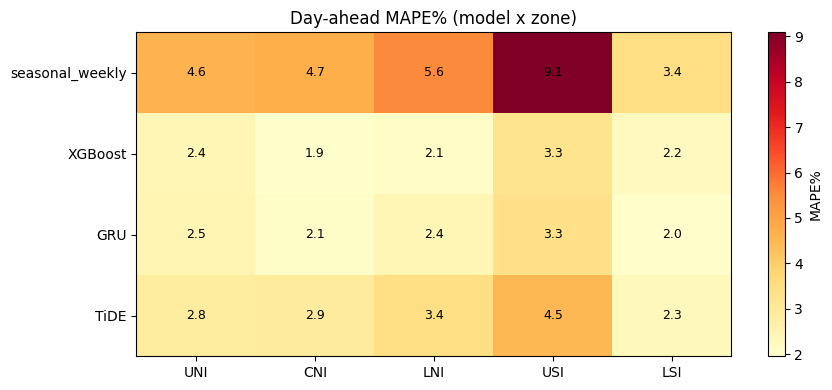

In [4]:
# day-ahead MAPE 透视表:模型 × 区域
pivot = (scores[scores.horizon == fu.H_DAY]
         .pivot(index="model", columns="zone", values="MAPE%")
         .reindex(["seasonal_weekly", "XGBoost", "GRU", "TiDE"])[ZONES])
print("=== Day-ahead MAPE% by model x zone ===")
display(pivot.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(ZONES))); ax.set_xticklabels(ZONES)
ax.set_yticks(range(len(pivot))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i,j]:.1f}", ha="center", va="center", fontsize=9)
ax.set_title("Day-ahead MAPE% (model x zone)"); fig.colorbar(im, label="MAPE%")
plt.tight_layout(); plt.show()

In [5]:
# week-ahead MAPE 透视表
pivot_w = (scores[scores.horizon == fu.H_WEEK]
           .pivot(index="model", columns="zone", values="MAPE%")
           .reindex(["seasonal_weekly", "XGBoost", "GRU", "TiDE"])[ZONES])
print("=== Week-ahead MAPE% by model x zone ===")
display(pivot_w.round(2))

=== Week-ahead MAPE% by model x zone ===


zone,UNI,CNI,LNI,USI,LSI
model,,,,,
seasonal_weekly,4.69,4.65,5.69,8.67,3.12
XGBoost,3.43,3.41,3.59,8.12,5.71
GRU,2.93,2.87,2.86,4.47,2.86
TiDE,4.69,4.57,5.94,8.23,2.79


## 4. 全国汇总 (National)

各区已对齐到同一时间网格、同一组预测原点,因此可直接按 (原点, 步长) **逐时段求和**得到全国
实际与全国预测,评估全国层面的预测精度。

In [6]:
nat_rows, nat_bt = [], {}
for m in ["seasonal_weekly", "XGBoost", "GRU", "TiDE"]:
    yt = sum(ZB[z][m]["y_true"] for z in ZONES)
    yp = sum(ZB[z][m]["y_pred"] for z in ZONES)
    nat_bt[m] = {"origins": origins, "y_true": yt, "y_pred": yp}
    nat_rows.append(fu.score(nat_bt[m], HORIZONS, m))
national = pd.concat(nat_rows, ignore_index=True).assign(zone="NATIONAL")
print("=== NATIONAL demand forecast accuracy ===")
display(national.sort_values(["horizon", "MAE"]).round(4).reset_index(drop=True))

=== NATIONAL demand forecast accuracy ===


,model,horizon,MAE,RMSE,MAPE%,sMAPE%,zone
0,GRU,48,0.0358,0.0464,1.4896,1.4930,NATIONAL
1,XGBoost,48,0.0403,0.0505,1.6862,1.7036,NATIONAL
2,TiDE,48,0.0544,0.0748,2.2487,2.2556,NATIONAL
3,seasonal_weekly,48,0.1006,0.1369,4.1083,4.0888,NATIONAL
4,GRU,336,0.0445,0.0577,1.9021,1.9140,NATIONAL
5,TiDE,336,0.0964,0.1302,4.0576,4.0444,NATIONAL
6,XGBoost,336,0.0975,0.1145,4.2212,4.3461,NATIONAL
7,seasonal_weekly,336,0.0987,0.1352,4.1142,4.1380,NATIONAL


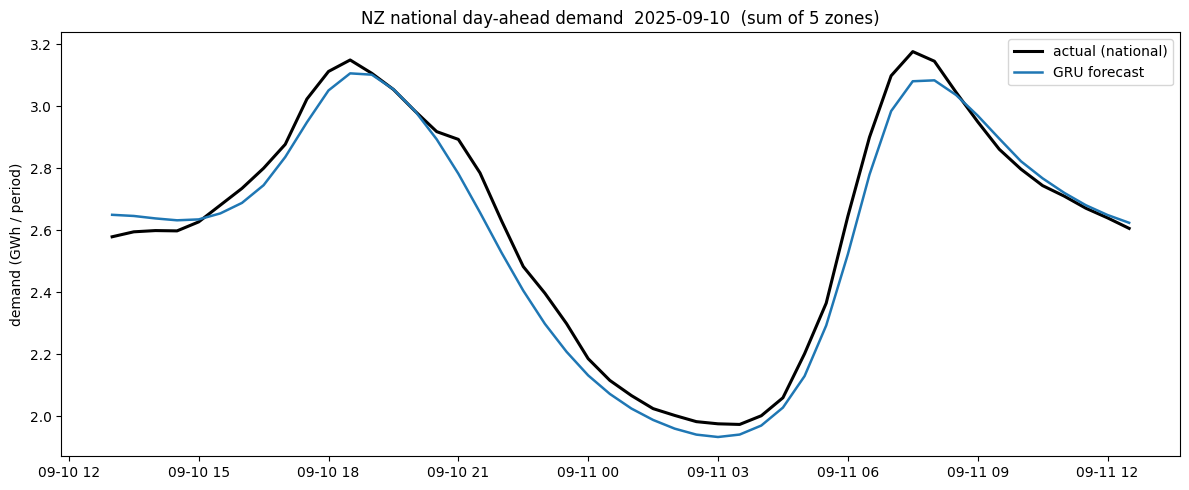

best national day-ahead model: GRU


In [7]:
# 全国日前预测示例(选当前最佳模型)
best_nat = national[national.horizon == fu.H_DAY].sort_values("MAE")["model"].iloc[0]
o = origins[len(origins) // 2]; h = fu.H_DAY; i = origins.index(o)
idx = common[o + 1: o + 1 + h].tz_convert(fu.TZ)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(idx, nat_bt[best_nat]["y_true"][i, :h], "k-", lw=2.2, label="actual (national)")
ax.plot(idx, nat_bt[best_nat]["y_pred"][i, :h], lw=1.8, label=f"{best_nat} forecast")
ax.set_title(f"NZ national day-ahead demand  {idx[0]:%Y-%m-%d}  (sum of 5 zones)")
ax.set_ylabel("demand (GWh / period)"); ax.legend(); plt.tight_layout(); plt.show()
print("best national day-ahead model:", best_nat)

In [8]:
# 保存所有区域 + 全国得分
out = pd.concat([scores, national], ignore_index=True)
out.to_csv(ROOT / "data" / "processed" / "scores_all_zones.csv", index=False)
print("saved scores_all_zones.csv"); out[out.horizon == fu.H_DAY].pivot_table(
    index="model", columns="zone", values="MAPE%").round(2)

saved scores_all_zones.csv


zone,CNI,LNI,LSI,NATIONAL,UNI,USI
model,,,,,,
GRU,2.06,2.40,1.98,1.49,2.50,3.35
TiDE,2.91,3.44,2.29,2.25,2.84,4.48
XGBoost,1.95,2.11,2.21,1.69,2.44,3.26
seasonal_weekly,4.70,5.57,3.45,4.11,4.60,9.09


---
### 小结
- 在全部 5 个区域上,**XGBoost / GRU** 通常最优,**TiDE** 紧随其后并稳定优于朴素基线;各区难度不同
  (人口密集、负荷规律强的区域 MAPE 更低)。
- 按时段求和得到的**全国**预测,因区域间误差部分抵消,通常 MAPE 低于多数单区。
- 这套统一框架(`forecast_utils` + `deep`)对任意区域即插即用,可作为全 NZ 需求预测的基础。

可继续:每区单独调参 / 概率区间;全局多区域联合模型(一个模型吃所有区域);
真实预报天气驱动的业务化预测。